# Belloni, 2022, $^{238}$U(n,f) cross section UQ as part of data preparation for GMA (Data release: LA-UR-25-32229)

In [1]:
import os
from importlib import reload
from numpy import array, shape, arange, ones, zeros, sqrt, loadtxt, allclose, interp, diag
from matplotlib.pyplot import xscale, loglog, errorbar, figure, show, plot, xlabel, ylabel, legend, xlim, ylim, semilogx

In [2]:
homedir = os.getcwd() +'/'

In [5]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [7]:
import Class_nfcs as Cnf
reload(Cnf)

<module 'Class_nfcs' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_nfcs.py'>

## Fission chamber 1 measurement (Pu-240/U-238)

In [10]:
# Reading higher energy data

datafile = homedir+'Belloni2022.txt'
alldata  = loadtxt(datafile)

Einc    = alldata[:,0]
Ersl    = alldata[:,1]*100.0/(2.355*Einc)
Data    = alldata[:,2] # absolute data, originally Pu-9/U-8(n,f). There is also the option of Pu-9/H-1, but that is systematically low. 
Totunc  = alldata[:,3]
neutronflux = alldata[:,6] # neutron flux,  From 1-H measurement.
statuncU    = alldata[:,7]
multscattU  = alldata[:,9] # multiple scattering in Pu FC
deteffunc   = alldata[:,11] # multiple scattering in U FC
impurityunc = 0.1 #% per the paper.

normunc_U = 2.0 #%
normunc_deadtime = 0.03 #%

H1_np_81 = array([2.5509276, 0.6507717])
H1_np_56 = array([2.5565908, 0.6558078])

correction_factor = H1_np_81/H1_np_56
Data = Data*correction_factor


print(sqrt(neutronflux*neutronflux+statuncU*statuncU+\
          multscattU*multscattU+deteffunc*deteffunc+\
          normunc_U*normunc_U*ones(shape(Einc)[0],dtype=float)+\
          normunc_deadtime*normunc_deadtime*ones(shape(Einc)[0],dtype=float)),Totunc)

print('If I add up all uncertainties provided in the EXFOR entry, I get very close to the EXFOR total uncertainties.')

[2.96082759 3.705307  ] [2.95 3.67]
If I add up all uncertainties provided in the EXFOR entry, I get very close to the EXFOR total uncertainties.


Text(0, 0.5, 'Relative Uncertainty (%)')

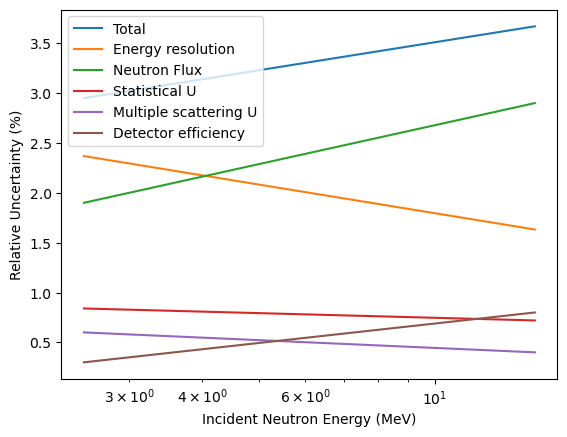

In [12]:
figure(1)
semilogx(Einc,Totunc,label='Total')
semilogx(Einc,Ersl,label='Energy resolution')
semilogx(Einc,neutronflux,label='Neutron Flux')
semilogx(Einc,statuncU,label='Statistical U')
semilogx(Einc,multscattU,label='Multiple scattering U')
semilogx(Einc,deteffunc,label='Detector efficiency')
legend()
xlabel('Incident Neutron Energy (MeV)')
ylabel('Relative Uncertainty (%)')

In [14]:
features = {"Author": ["Belloni", "Eykens", "Heyse", "Matei", "Moens", "Nolte", "Plompen", "Richter", "Sibbens", "Vanleeuw", "Wynants"],\
"Year": "2022",\
'Absolute':'Yes','GMAnumber':6011,\
'MonitorReaction':'(1-H-1(N,EL)1-H-1,,DA)','EXFORnumber':'23653004',\
'Facility':['VDG','2GERPTB'],'Institute':['"2GERPTB","2ZZZGEL","3RUMRUM"'],\
'Isotope':['U-238','H-1'],'quantity': 'cs', 'reaction': 'n,f',\
'MeasurementType':'Absolute','ConcernEXFOR':'None',\
'AcceptedVsRejected':'accepted',\
'BackgroundCorrected':'y',\
"AlphaBackground": "y",
"GammaBackground": "y",
"RandomCoincidenceBackground": "y",
"ShadowBarBackground": "N/A",
"WrapAroundBackground": "N/A",
"MultipleScatteringSampleBackingCorrected": "y",
"MultipleScatteringSurroundingCorrected": "y",
"AttenuationSampleBackingCorrected": "y",
"AttenuationSurroundingCorrected": "y",
"FissionDetectionEfficiencyCorrected": "y",'StoppingPowerCorrected':'y',\
'SampleRoughnessCorrected':'unknown',\
"SampleDecayCorrected": "y",
"FissionFragmentAbsorptioninSampleCorrected": "y",
"SignalPulsePileupCorrected": "y",
"DeadtimeCorrected": "y",
"AngularDistributionFissionFragmentsCorrected": "y",
"ImpuritiesCorrected": "y",
'ForwardBoostCorrected':'unknown',\
'SpectrumExtrapolationCorrected':'y',\
'FissionDetector':{'Type':['FISCH','FC1'],'ParticleDetected':'FF',\
'Efficiency':'unknown','EfficiencyMethod':['threshold selection','spectrum extrapolation below threshold','MC (stopping power)'],\
'FFAbsorptionAngularDistributionMethod':'MC',\
'AngularAcceptaneofFF':'unknown',\
'Gas':{'Type':['Ar','CH4'],'Purity':[90.0,10.0],'Pressure': 1016,'Pressure_unit':'hPa'},\
'Size':{'geometry':'unknown'},\
'NoPhotomultipliers':'unknown',\
'Weight':'unknown','StructuralMaterial':'Al','ReferenceDetector':'FISCH'},\
'NeutronFluxDetector':{'Type':['TELES','LONGC'],'Number':2,'ParticleDetected':['P','N'],\
'Efficiency':'unknown','ResponseDeterminationMethod':['relative to H-1'],\
'EfficiencyDeterminationMethod':['relative to H-1'],'Angle':[0,98],\
'Gas':{'Type':'unknown','Purity':'unknown','Pressure':'unknown'},\
'Size':{'geometry':'unknown','diameter':'unknown','diameter_unit':'unknown'},\
'NoPhotomultipliers':'unknown','Photomultipliers':'unknown',\
'Weight':'unknown','StructuralMaterial':'unknown',\
'ReferenceDetector':'N/A','ReferenceReaction':'H-1'},\
'Shielding':{'Material':'unknown',\
'Size':{'Geometry':'unknown','Length':'unknown','Length_unit':'unknown'},'DistanceFromNeutronDetector':'unknown',\
'Purpose':'unknown'},\
'Sample':{'Activity':{'238U':10.04},'Activity_unit':'bq','Reused':'no',\
'Form':'deposits','Mass':{'238U':114.6},'Mass_unit':'mug/cm2',\
'Diameter':[3.0,3.0],'Diameter_unit':'cm','Thickness':'unknown','Thickness_unit':'unknown',\
'Homogenity':'unknown',\
'Contaminants':{'238U':{'238U':99.9992233,'234U':0.0000592,'235U':0.07668,'236U':0.0009226}},\
'BackingMaterial':['Al'],'BackingDiameter':[5.0],'Diameter_unit':'cm',\
'BackingThickness':[0.25],'BackingThicknessUnit':'mm','DecayDeterminationMethod':'unknown',\
'Configuration':'back-to-back',\
'Fabrication':'molecular plated',\
'ImpurityDetermination':['alpha counting','calculated'],\
'NumberOfAtomsInSampleDeterminationTechnique':'alpha counting'},\
'BackgroundMethods':{'General':['PhD','measured'],'Wraparound':'N/A','alpha':'PhD',\
'Gamma':'PhD','RandomCoincidence':'measured (beam-off, spontaneous. fission)'},\
'MultipleScatteringMethods':{'InSample':['MC','calculated'],'Surrounding':['MC','calculated','design']},\
'AttenuationMethods':{'InSample':['MC','calculated'],'Surrounding':['MC','calculated','design']},\
'DeadtimeDeterminationMethod':'measured (with pulser)',\
'EnergyDetermination':'mono-energetic',\
'NeutronBeam':{'Facility':['VDG','2GERPTB'],'PulseWidth':'unknown','PulseWidthUnit':'N/A',\
'NeutronProducingReaction':['P-T','D-T'],'Target':['Ti','T'],\
'EnergySpread':'unknown','Monitor':'N-P',\
'Diameter':'unknown','Diameter_unit':'N/A','TimeGateOpen':'N/A','TimeGateOpen_unit':'N/A',\
'TOFLength':{'Value':{'2.51MeV':158.6,'14.83MeV':206.6},'Unit': 'mm','Unc':'unknown','Unit_Unc':'N/A'},\
'trsl':{'Value':'unknown','Unit':'ns','Measure':'N/A'},\
't0Determination':'unknown'}
}

In [16]:
backgrduncU = 0.2*ones(shape(Data)[0],dtype=float)

Testing covariance matrix of type Positive_fully:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

/Users/dneudecker/Documents/Codes/ARIADNE-github/
REFERENCE_LIBRARY_FILE: /Users/dneudecker/Documents/Codes/ARIADNE-github/Data/ReferenceData_dict.txt
{'isotope': 'U-238', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}


/Users/dneudecker/Documents/Codes/ARIADNE-github/src/BasicPhysicsFunctions.py:230: RuntimeWarning: invalid value encountered in scalar divide
  data_derivative[index] = (data[index+1]-data[index])/(lattice[1+index]-lattice[index])


Testing cov_eunc covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing total covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

WIP: not yet included. No Xml file produced.

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/U-238/nfcs_DS6011Belloni/Belloni2022.xml
{'isotope': 'U-238', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/U-238/nfcs_DS6011Belloni/Belloni2022EUCLID.json

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/U-238/nfcs_DS6011Belloni/Partial_Unc.dat

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/U-238/nfcs_DS6011Belloni/TotalCor.dat


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


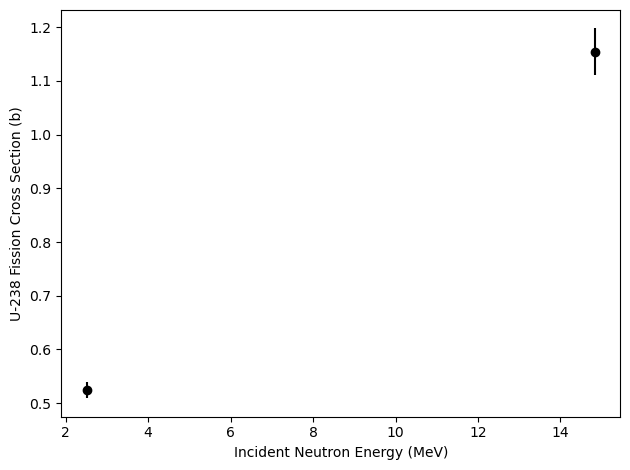

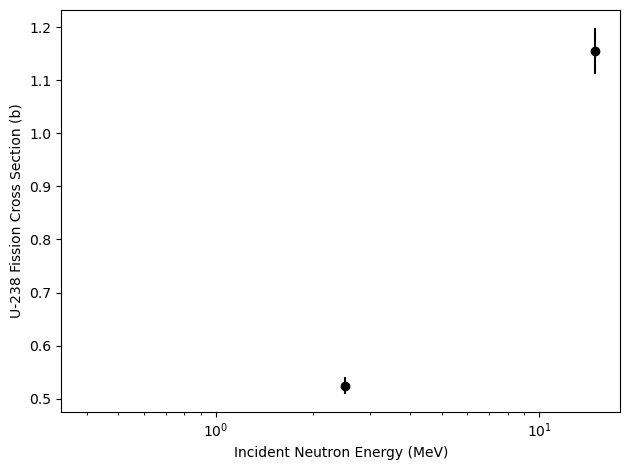

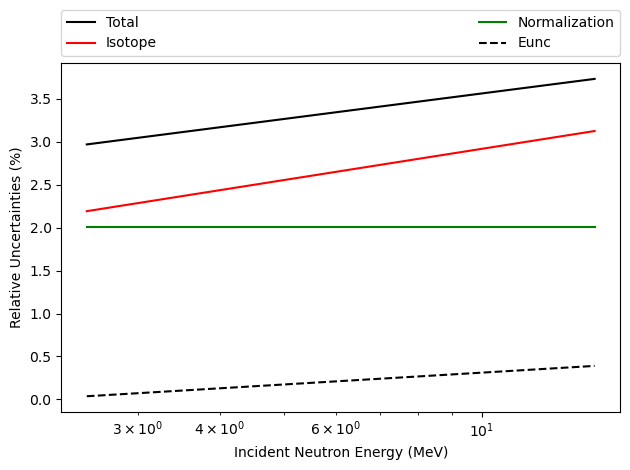

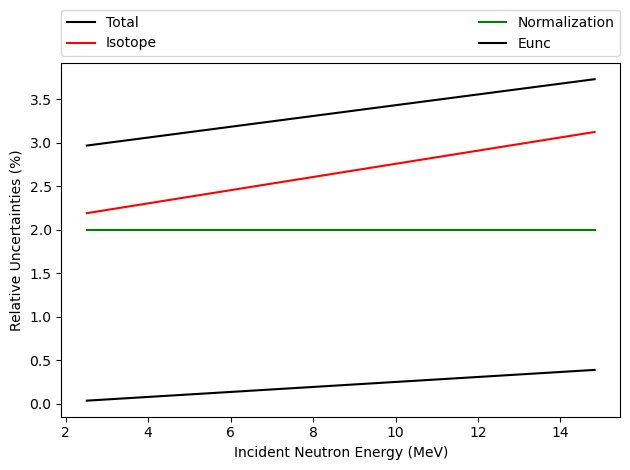

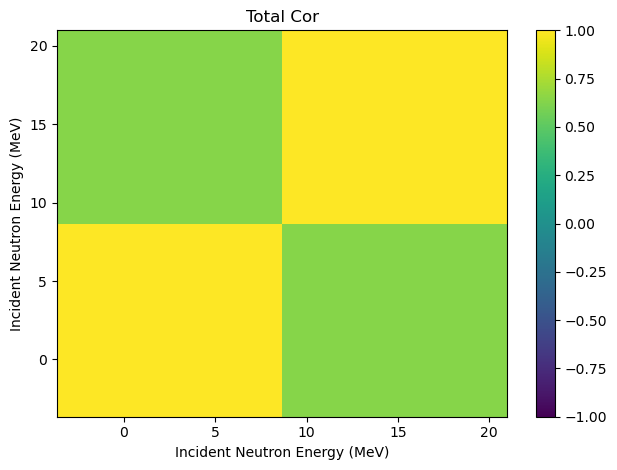

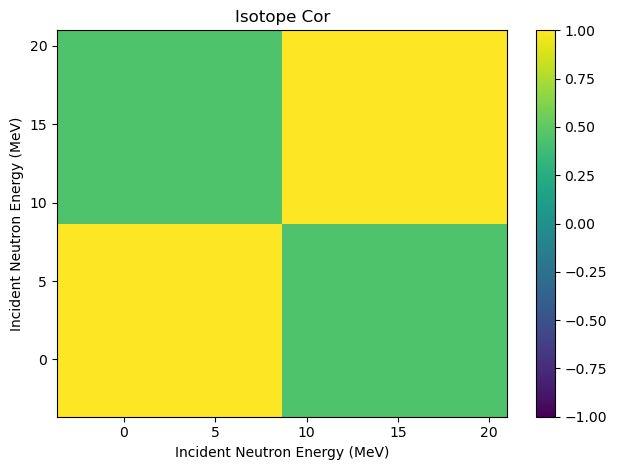

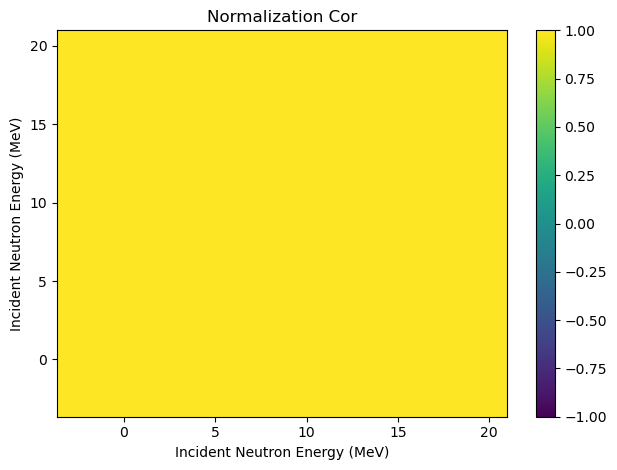

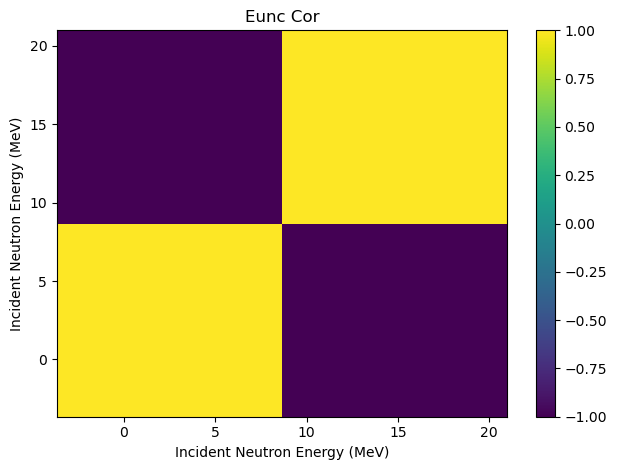

In [18]:
Documentation = """EXFOR No. = 23653004; Belloni et al., European Physical Journal A: Hadrons and Nuclei, Vol.58, p.227 (2022). 
+) They give two U-238 cross sections because they used two different samples in two different, but identically built fission chambers. I treat them as separate measurements with correlated uncertainties.
+) This is the measurement of FC1 with Pu-240 and U-238.
+) Partial uncertainties for all uncertainties given that I would expect from the templates except for background. Very detailed.
+) Missing correction: forward boost.
+) This is an absolute measurement in ratio to H-1. Unfortunately, theu used H-1 angular distribution from ENDF/B-V.0), which changed by about 1%. I re-normalized with a correction factor provided by Roberto.
+) My only concern regarding corrections is that the forward-boost is not mentioned and that matters for the 14-MeV point.
+) Correlated uncertainties: neutron flux, deadtime, number of target atoms (same method, 0.5), multiple scattering (same method, different samples in beam 0.5), det eff. (same methods, different sample in beam).\
+) The only uncertainty not provided is background. They state that the background for U-238 is very low. I used the template value of 0.2%"""


general_info = {'name': 'Belloni2022', 'isotope': 'U-238', 'quantity': 'cs', 'reaction': 'n,f', \
                'output_file' : homedir+'Belloni2022.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}

resolution = {'energy_resolution': Ersl*Einc*2.355/100.0,
              'energy_resolution_unit': 'MeV'
              }

einc_unc = {'en_err' : {'enerr_unc': array(Ersl*0.2),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\
            'identifier_iso_deriv1' : 'ENDF/B-VIII.0','resolution':resolution}

normalization = sqrt(normunc_U*normunc_U+normunc_deadtime*normunc_deadtime+impurityunc*impurityunc)


norm_unc = {'value': normalization, 'unit':'%'}

unc_iso = {'einc_unc': einc_unc, 'normalization_unc':norm_unc,\
           'values':array([statuncU,backgrduncU,multscattU,neutronflux,deteffunc]).transpose(),\
           'units':['%','%','%','%','%'],\
           'type':['Diagonal','Gaussian','Gaussian',\
                   'Gaussian','Gaussian'],\
           'type_arg':{'einc':array(Einc),'damp_term':[1.0,1.0,1.0,1.0,1.0],}}

data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(Data), 'values_unit': "b" }


DS6011_nfcs = Cnf.nfcs_absolute(general_info,data,unc_iso,features)

[2.36844554 1.63208507]
[0.47368899 0.32641701]


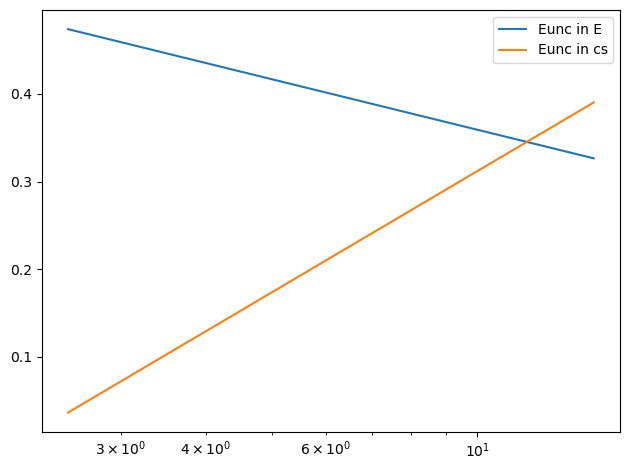

In [20]:
# get energy uncertainties in energy
dim = shape(Einc)[0]
cscov = DS6011_nfcs.cov_eunc
Euncov = zeros([dim,dim],dtype=float)

deriv_nucdata = [ -0.01617405,  0.09305994
]

for index1 in arange(0,dim):
    for index2 in arange(0,dim):
        Euncov[index1,index2]=cscov[index1,index2]*\
        Data[index1]*Data[index2]/\
        (Einc[index1]*Einc[index2]*deriv_nucdata[index1]*deriv_nucdata[index2])

Euncrelunc = sqrt(diag(Euncov))
semilogx(Einc,Euncrelunc)
semilogx(Einc,sqrt(diag(cscov)))
legend(['Eunc in E','Eunc in cs'])
print(Ersl)
print(Euncrelunc)

In [26]:
GMAnewnumber='6011'
year = features["Year"]
authors = 'Belloni (FC1)'
journal = 'J,EPJ-A,58(2022)'
        

normalizationunc = [normunc_U,impurityunc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]


uncertainty_descriptor = ['UNCERTAINTIES','1 Normal. unc.: U8 normalization, impurity (deadtime negligible)',\
                          '1 Energy unc. assumed to be 20% of energy resolution.',\
                          '2 Energy resl explicitly given.',\
                          '3 Statistical Unc.','4 small background from templates (background small)',\
                          '5 Multiple scattering and attenuation uncertainty',\
                          '6 Neutron flux unc.',\
                          '7 Detector efficiency unc. (Zero bias corr. of 238U)',\
                          'Forward boost correction not mentioned.',\
                          'Data extracted from a Pu-240/U-238 measurement (neutron flux measured by H-1 too).']
abc_components = ones([11,3],dtype=float)*0.5
abc_components[0,:] = [0.99, 0.01,0.5]
abc_components[1:3,:] = zeros([2,3],dtype=float)
abc_components[3,:] = [0.1, 0.9,0.01]
abc_components[4:7,:] = [0.99,0.01,0.5]
#abc_components[5,:] = [0.0, 1.0,0.01]

uncertainties = zeros([dim,12],dtype=float)
uncertainties[:,:5] = array([statuncU,backgrduncU,multscattU,neutronflux,deteffunc]).transpose()
controlnumber = [0,0,9,1,1,1,1,0,0,0,0]

data = {'einc': Einc, 'einc_unit': 'MeV', 'values':Data, 'values_unit': "none" }
Enrsl = Ersl
Eunc = Euncrelunc
abs_shape = 'absolute'
reference = 'none'

In [30]:
import WriteGMAOutput as WGMA
output = WGMA.WriteGMAOutput(GMAnewnumber,year,authors,journal,general_info,uncertainty_descriptor,data,reference,\
                     abs_shape,abc_components,Eunc,Enrsl,uncertainties,controlnumber,normalizationunc)

5
5
5
5
5
5
5
5
5
5


## Fission chamber 2 measurement (Pu-242/U-238)

In [ ]:
# Reading higher energy data

datafile = homedir+'Belloni2022.txt'
alldata  = loadtxt(datafile)

Einc    = alldata[:,0]
Ersl    = alldata[:,1]*100.0/(2.355*Einc)
Data    = alldata[:,4] # absolute data, originally Pu-9/U-8(n,f). There is also the option of Pu-9/H-1, but that is systematically low. 
Totunc  = alldata[:,5]
neutronflux = alldata[:,6] # neutron flux. From 1-H measurement.
statuncU    = alldata[:,8]
multscattU  = alldata[:,10] # multiple scattering in Pu FC
deteffunc   = alldata[:,11] # multiple scattering in U FC
impurityunc = 0.1 #% per the paper.

normunc_U = 1.9 #%
normunc_deadtime = 0.03 #%

correction_factor = H1_np_81/H1_np_56
Data = Data*correction_factor

print(sqrt(neutronflux*neutronflux+statuncU*statuncU+\
          multscattU*multscattU+deteffunc*deteffunc+\
          normunc_U*normunc_U*ones(shape(Einc)[0],dtype=float)+\
          normunc_deadtime*normunc_deadtime*ones(shape(Einc)[0],dtype=float)),Totunc)

print('If I add up all uncertainties provided in the EXFOR entry, I get very close to the EXFOR total uncertainties.')

In [ ]:
figure(1)
semilogx(Einc,Totunc,label='Total')
semilogx(Einc,Ersl,label='Energy resolution')
semilogx(Einc,neutronflux,label='Neutron Flux')
semilogx(Einc,statuncU,label='Statistical U')
semilogx(Einc,multscattU,label='Multiple scattering U')
semilogx(Einc,deteffunc,label='Detector efficiency')
legend()
xlabel('Incident Neutron Energy (MeV)')
ylabel('Relative Uncertainty (%)')

In [ ]:
features = {"Author": ["Belloni", "Eykens", "Heyse", "Matei", "Moens", "Nolte", "Plompen", "Richter", "Sibbens", "Vanleeuw", "Wynants"],\
"Year": "2022",\
'Absolute':'Yes','GMAnumber':6012,\
'MonitorReaction':'(1-H-1(N,EL)1-H-1,,DA)','EXFORnumber':'23653004',\
'Facility':['VDG','2GERPTB'],'Institute':['"2GERPTB","2ZZZGEL","3RUMRUM"'],\
'Isotope':['U-238','H-1'],'quantity': 'cs', 'reaction': 'n,f',\
'MeasurementType':'Absolute','ConcernEXFOR':'None',\
'AcceptedVsRejected':'accepted',\
'BackgroundCorrected':'y',\
"AlphaBackground": "y",
"GammaBackground": "y",
"RandomCoincidenceBackground": "y",
"ShadowBarBackground": "N/A",
"WrapAroundBackground": "N/A",
"MultipleScatteringSampleBackingCorrected": "y",
"MultipleScatteringSurroundingCorrected": "y",
"AttenuationSampleBackingCorrected": "y",
"AttenuationSurroundingCorrected": "y",
"FissionDetectionEfficiencyCorrected": "y",'StoppingPowerCorrected':'y',\
'SampleRoughnessCorrected':'unknown',\
"SampleDecayCorrected": "y",
"FissionFragmentAbsorptioninSampleCorrected": "y",
"SignalPulsePileupCorrected": "y",
"DeadtimeCorrected": "y",
"AngularDistributionFissionFragmentsCorrected": "y",
"ImpuritiesCorrected": "y",
'ForwardBoostCorrected':'unknown',\
'SpectrumExtrapolationCorrected':'y',\
'FissionDetector':{'Type':['FISCH','FC2'],'ParticleDetected':'FF',\
'Efficiency':'unknown','EfficiencyMethod':['threshold selection','spectrum extrapolation below threshold','MC (stopping power)'],\
'FFAbsorptionAngularDistributionMethod':'MC',\
'AngularAcceptaneofFF':'unknown',\
'Gas':{'Type':['Ar','CH4'],'Purity':[90.0,10.0],'Pressure': 1016,'Pressure_unit':'hPa'},\
'Size':{'geometry':'unknown'},\
'NoPhotomultipliers':'unknown',\
'Weight':'unknown','StructuralMaterial':'Al','ReferenceDetector':'FISCH'},\
'NeutronFluxDetector':{'Type':['TELES','LONGC'],'Number':2,'ParticleDetected':['P','N'],\
'Efficiency':'unknown','ResponseDeterminationMethod':['relative to H-1'],\
'EfficiencyDeterminationMethod':['relative to H-1'],'Angle':[0,98],\
'Gas':{'Type':'unknown','Purity':'unknown','Pressure':'unknown'},\
'Size':{'geometry':'unknown','diameter':'unknown','diameter_unit':'unknown'},\
'NoPhotomultipliers':'unknown','Photomultipliers':'unknown',\
'Weight':'unknown','StructuralMaterial':'unknown',\
'ReferenceDetector':'N/A','ReferenceReaction':'H-1'},\
'Shielding':{'Material':'unknown',\
'Size':{'Geometry':'unknown','Length':'unknown','Length_unit':'unknown'},'DistanceFromNeutronDetector':'unknown',\
'Purpose':'unknown'},\
'Sample':{'Activity':{'238U':10.71},'Activity_unit':'bq','Reused':'no',\
'Form':'deposits','Mass':{'238U':112.2},'Mass_unit':'mug/cm2',\
'Diameter':[3.0,3.0],'Diameter_unit':'cm','Thickness':'unknown','Thickness_unit':'unknown',\
'Homogenity':'unknown',\
'Contaminants':{'238U':{'238U':99.9992233,'234U':0.0000592,'235U':0.07668,'236U':0.0009226}},\
'BackingMaterial':['Al'],'BackingDiameter':[5.0],'Diameter_unit':'cm',\
'BackingThickness':[0.25],'BackingThicknessUnit':'mm','DecayDeterminationMethod':'unknown',\
'Configuration':'back-to-back',\
'Fabrication':'molecular plated',\
'ImpurityDetermination':['alpha counting','calculated'],\
'NumberOfAtomsInSampleDeterminationTechnique':'alpha counting'},\
'BackgroundMethods':{'General':['PhD','measured'],'Wraparound':'N/A','alpha':'PhD',\
'Gamma':'PhD','RandomCoincidence':'measured (beam-off, spontaneous. fission)'},\
'MultipleScatteringMethods':{'InSample':['MC','calculated'],'Surrounding':['MC','calculated','design']},\
'AttenuationMethods':{'InSample':['MC','calculated'],'Surrounding':['MC','calculated','design']},\
'DeadtimeDeterminationMethod':'measured (with pulser)',\
'EnergyDetermination':'mono-energetic',\
'NeutronBeam':{'Facility':['VDG','2GERPTB'],'PulseWidth':'unknown','PulseWidthUnit':'N/A',\
'NeutronProducingReaction':['P-T','D-T'],'Target':['Ti','T'],\
'EnergySpread':'unknown','Monitor':'N-P',\
'Diameter':'unknown','Diameter_unit':'N/A','TimeGateOpen':'N/A','TimeGateOpen_unit':'N/A',\
'TOFLength':{'Value':{'2.51MeV':158.6,'14.83MeV':206.6},'Unit': 'mm','Unc':'unknown','Unit_Unc':'N/A'},\
'trsl':{'Value':'unknown','Unit':'ns','Measure':'N/A'},\
't0Determination':'unknown'}
}

In [ ]:
backgrduncU = 0.2*ones(shape(Data)[0],dtype=float)

In [ ]:
Documentation = """EXFOR No. = 23653004; Belloni et al., European Physical Journal A: Hadrons and Nuclei, Vol.58, p.227 (2022). 
+) They give two U-238 cross sections because they used two different samples in two different, but identically built fission chambers. I treat them as separate measurements with correlated uncertainties.
+) This is the measurement of FC2 with Pu-242 and U-238.
+) Partial uncertainties for all uncertainties given that I would expect from the templates except for background. Very detailed.
+) Missing correction: forward boost.
+) This is an absolute measurement in ratio to H-1. Unfortunately, theu used H-1 angular distribution from ENDF/B-V.0), which changed by about 1%. I re-normalized with a correction factor provided by Roberto.
+) My only concern regarding corrections is that the forward-boost is not mentioned and that matters for the 14-MeV point.
+) Correlated uncertainties: neutron flux, deadtime, number of target atoms (same method, 0.5), multiple scattering (same method, different samples in beam 0.5), det eff. (same methods, different sample in beam).\
+) The only uncertainty not provided is background. They state that the background for U-238 is very low. I used the template value of 0.2%"""


general_info = {'name': 'Belloni2022', 'isotope': 'U-238', 'quantity': 'cs', 'reaction': 'n,f', \
                'output_file' : homedir+'Belloni2022.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}


#einc_unc = {'en_err' : {'enerr_unc': array(Ersl),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\
#            'identifier_iso_deriv1' : 'ENDF/B-VIII.0'}

resolution = {'energy_resolution': Ersl*Einc*2.355/100.0,
              'energy_resolution_unit': 'MeV'
              }

einc_unc = {'en_err' : {'enerr_unc': array(Ersl*0.2),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\
            'identifier_iso_deriv1' : 'ENDF/B-VIII.0','resolution':resolution}

normalization = sqrt(normunc_U*normunc_U+normunc_deadtime*normunc_deadtime+impurityunc*impurityunc)


norm_unc = {'value': normalization, 'unit':'%'}

unc_iso = {'einc_unc': einc_unc, 'normalization_unc':norm_unc,\
           'values':array([statuncU,backgrduncU,multscattU,neutronflux,deteffunc]).transpose(),\
           'units':['%','%','%','%','%'],\
           'type':['Diagonal','Gaussian','Gaussian',\
                   'Gaussian','Gaussian'],\
           'type_arg':{'einc':array(Einc),'damp_term':[1.0,1.0,1.0,1.0,1.0],}}

data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(Data), 'values_unit': "b" }


DS6012_nfcs = Cnf.nfcs_absolute(general_info,data,unc_iso,features)

In [ ]:
GMAnewnumber='6012'
year = features["Year"]
authors = 'Belloni (FC2)'
journal = 'J,EPJ-A,58(2022)'
        

normalizationunc = [normunc_U,impurityunc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]


uncertainty_descriptor = ['UNCERTAINTIES','1 Normal. unc.: U8 normalization, impurity (deadtime negligible)',\
                          '1 Energy unc. assumed to be 20% of energy resolution.',\
                          '2 Energy resl explicitly given.',\
                          '3 Statistical Unc.','4 small background from templates (background small)',\
                          '5 Multiple scattering and attenuation uncertainty',\
                          '6 Neutron flux unc.',\
                          '7 Detector efficiency unc. (Zero bias corr. of 238U)',\
                          'Forward boost correction not mentioned.',\
                          'Data extracted from a Pu-242/U-238 measurement (neutron flux measured by H-1 too).']
abc_components = ones([11,3],dtype=float)*0.5
abc_components[0,:] = [0.99, 0.01,0.5]
abc_components[1:3,:] = zeros([2,3],dtype=float)
abc_components[3,:] = [0.1, 0.9,0.01]
abc_components[4:7,:] = [0.99,0.01,0.5]
#abc_components[5,:] = [0.0, 1.0,0.01]

uncertainties = zeros([dim,12],dtype=float)
uncertainties[:,:5] = array([statuncU,backgrduncU,multscattU,neutronflux,deteffunc]).transpose()



controlnumber = [0,0,9,1,1,1,1,0,0,0,0]
print(abc_components, uncertainties)

data = {'einc': Einc, 'einc_unit': 'MeV', 'values':Data, 'values_unit': "none" }
Enrsl = Ersl
Eunc = Euncrelunc
abs_shape = 'absolute'
reference = 'none'

In [ ]:
import WriteGMAOutput as WGMA
print(WGMA.WriteGMAOutput(GMAnewnumber,year,authors,journal,general_info,uncertainty_descriptor,data,reference,\
                     abs_shape,abc_components,Eunc,Enrsl,uncertainties,controlnumber,normalizationunc))

In [ ]:
cd '/Users/dneudecker/Documents/Codes/dryad/build/python'

In [ ]:
import dryad
import numpy as np

In [ ]:
U238= dryad.ProjectileTarget.from_endf_file( '/Users/dneudecker/Documents/library/neutrons-version.VIII.1-endf6format/n-092_U_238.endf' )

In [ ]:
id1 = dryad.id.ReactionID( 'n,U238->fission' ) # 'n,Mg24->n(0)', 'n,Mg24->2n(0)', 'n,Mg24->total/capture', 'n,Mg24->n(t)' this is inelastic not including elastic
xs1 = U238.reaction( id1 ).cross_section
xs  = xs1.linearise()

Einc81 = 1.0e-6*array(xs.energies)
xs81   = array(xs.values)

In [ ]:
print(DS6011_nfcs.data_total['einc'],DS6011_nfcs.data_total['data'],DS6011_nfcs.data_total['rel_unc'])

In [ ]:
xlim([2.0,15.0])
ylim([0.5,1.4])
errorbar(DS6011_nfcs.data_total['einc'],DS6011_nfcs.data_total['data'],\
         DS6011_nfcs.data_total['rel_unc']*DS6011_nfcs.data_total['data'],fmt='s')
errorbar(DS6012_nfcs.data_total['einc'],DS6012_nfcs.data_total['data'],\
         DS6012_nfcs.data_total['rel_unc']*DS6012_nfcs.data_total['data'],fmt='.')
plot(Einc81,xs81)
legend(['VIII.1','Belloni-FC1','Belloni-FC2'])
xlabel('Incident Neutron Energy (MeV)')
ylabel('Cross Section (b)')